In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/synthetic/kavach_synthetic.csv')

print("Dataset loaded:", df.shape)
print(f"\nAdvisory speed range:")
print(f"  Min: {df['advisory_speed_kmh'].min()} km/h")
print(f"  Max: {df['advisory_speed_kmh'].max()} km/h")
print(f"  Avg: {df['advisory_speed_kmh'].mean():.1f} km/h")


Dataset loaded: (10000, 16)

Advisory speed range:
  Min: 8.2 km/h
  Max: 130.0 km/h
  Avg: 65.4 km/h


In [5]:

# Input features for speed profiler
X = df[['speed_kmh', 'weather_index', 'freight_load_tonnes',
        'section_speed_limit', 'section_incident_rate',
        'deceleration_rate', 'rfid_read_success']]

# Target - advisory speed
y = df['advisory_speed_kmh']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Features:", list(X.columns))
print(f"\nTraining set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")
print(f"\nTarget range:")
print(f"  Min: {y.min()} km/h")
print(f"  Max: {y.max()} km/h")






Features: ['speed_kmh', 'weather_index', 'freight_load_tonnes', 'section_speed_limit', 'section_incident_rate', 'deceleration_rate', 'rfid_read_success']

Training set: (8000, 7)
Testing set:  (2000, 7)

Target range:
  Min: 8.2 km/h
  Max: 130.0 km/h


In [6]:
# Create and train the model
print("Training the Speed Profiler...")

model = RandomForestRegressor(
    n_estimators=100,    # 100 decision trees
    max_depth=10,        # how deep each tree goes
    random_state=42,
    n_jobs=-1            # use all CPU cores for speed
)

model.fit(X_train, y_train)
print("Training complete!")

# Make predictions
y_pred = model.predict(X_test)

# Enforce the hard rule - never exceed section speed limit
y_pred_capped = np.minimum(y_pred, X_test['section_speed_limit'].values)

print(f"\nFirst 5 predictions vs actual:")
for i in range(5):
    print(f"  Predicted: {y_pred_capped[i]:.1f} km/h  |  "
          f"Actual: {y_test.iloc[i]:.1f} km/h  |  "
          f"Limit: {X_test['section_speed_limit'].iloc[i]} km/h")

Training the Speed Profiler...
Training complete!

First 5 predictions vs actual:
  Predicted: 90.6 km/h  |  Actual: 91.2 km/h  |  Limit: 110 km/h
  Predicted: 38.8 km/h  |  Actual: 38.9 km/h  |  Limit: 90 km/h
  Predicted: 60.3 km/h  |  Actual: 60.2 km/h  |  Limit: 130 km/h
  Predicted: 74.1 km/h  |  Actual: 73.9 km/h  |  Limit: 100 km/h
  Predicted: 89.4 km/h  |  Actual: 89.8 km/h  |  Limit: 110 km/h


  SPEED PROFILER EVALUATION
  RMSE : 0.72 km/h
  MAE  : 0.50 km/h
  R²   : 0.9986

Speed limit violations: 0
(should be 0 — model never exceeds section limit)


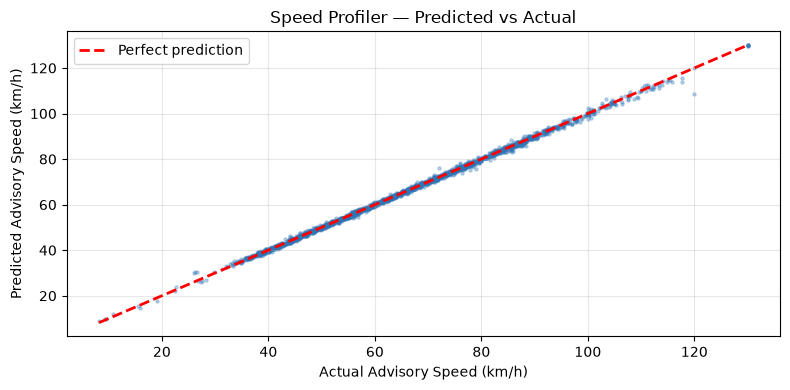

In [7]:
# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred_capped))
mae  = mean_absolute_error(y_test, y_pred_capped)
r2   = r2_score(y_test, y_pred_capped)

print("=" * 40)
print("  SPEED PROFILER EVALUATION")
print("=" * 40)
print(f"  RMSE : {rmse:.2f} km/h")
print(f"  MAE  : {mae:.2f} km/h")
print(f"  R²   : {r2:.4f}")
print("=" * 40)

# Verify hard cap is respected
violations = (y_pred_capped > X_test['section_speed_limit'].values).sum()
print(f"\nSpeed limit violations: {violations}")
print("(should be 0 — model never exceeds section limit)")

# Plot predicted vs actual
plt.figure(figsize=(8, 4))
plt.scatter(y_test, y_pred_capped, alpha=0.3, s=5, color='#2E75B6')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Advisory Speed (km/h)')
plt.ylabel('Predicted Advisory Speed (km/h)')
plt.title('Speed Profiler — Predicted vs Actual')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

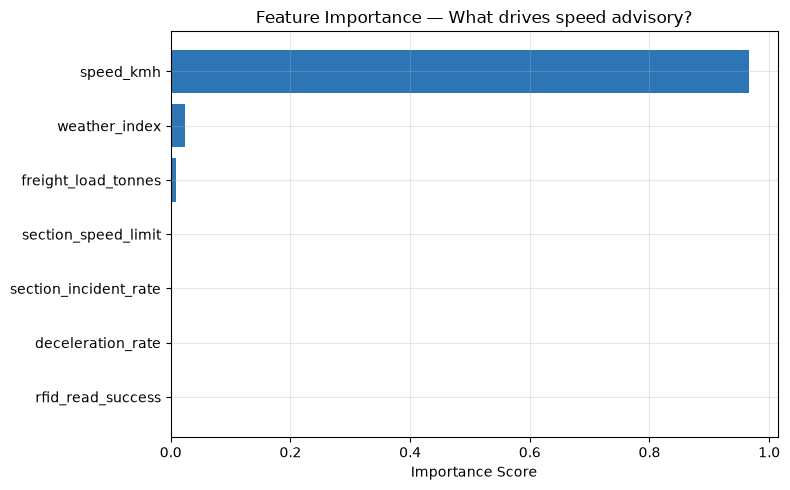


Top 3 most important features:
  speed_kmh: 0.9657
  weather_index: 0.0238
  freight_load_tonnes: 0.0082


In [8]:
# Which features matter most for speed advisory?
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance['feature'], importance['importance'], color='#2E75B6')
plt.title('Feature Importance — What drives speed advisory?')
plt.xlabel('Importance Score')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 3 most important features:")
top3 = importance.sort_values('importance', ascending=False).head(3)
for i, row in top3.iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

In [9]:
os.makedirs('../models/saved', exist_ok=True)

# Save the model
joblib.dump(model, '../models/saved/speed_profiler.pkl')

print("✅ Speed profiler saved: models/saved/speed_profiler.pkl")

# Verify by reloading
loaded = joblib.load('../models/saved/speed_profiler.pkl')
test_input = X_test.iloc[0:1]
test_pred  = loaded.predict(test_input)
test_limit = X_test['section_speed_limit'].iloc[0]
final_pred = min(test_pred[0], test_limit)

print(f"\n✅ Model reloaded successfully!")
print(f"   Test prediction:  {final_pred:.1f} km/h")
print(f"   Section limit:    {test_limit} km/h")
print(f"   Safe to operate:  {'YES' if final_pred <= test_limit else 'NO'}")

✅ Speed profiler saved: models/saved/speed_profiler.pkl

✅ Model reloaded successfully!
   Test prediction:  90.6 km/h
   Section limit:    110 km/h
   Safe to operate:  YES
